# Oleksii Krasnoshtanov Research Notebook

## Task 9-12: Method, Results, Analysis, and Synthesis

Research topic: Real-time audio-visual deepfake generation quality-latency tradeoff.

This notebook is designed to evidence the already executed pipeline using stored artifacts, without rerunning heavy GPU generation.

Coverage mapping:
- Task 9 (ILO 7.3A): Method implementation and experimental setup
- Task 10 (ILO 7.3B): Quantitative results and evaluation
- Task 11 (ILO 7.3C): Critical analysis and hypothesis testing
- Task 12 (ILO 7.3D): Synthesis, limitations, and future directions

## 1. Environment Setup and Evidence Paths

In [2]:
from pathlib import Path
import json
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

pd.set_option('display.max_columns', 200)
pd.set_option('display.width', 200)
sns.set_theme(style='whitegrid')

def find_project_root(start: Path) -> Path:
    current = start.resolve()
    for candidate in [current] + list(current.parents):
        if (candidate / 'pyproject.toml').exists() or (candidate / '.git').exists():
            return candidate
    return current

ROOT = find_project_root(Path.cwd())
NOTEBOOK_DIR = Path.cwd()
CHECKPOINT_DIR = ROOT / 'Datalab tasks' / 'checkpoints'
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)

CANDIDATE_AUDIO = [
    ROOT / 'results' / 'global_test' / 'audio_evaluation_results.csv',
    ROOT / 'results' / 'audio_evaluation_results.csv',
]
CANDIDATE_VIDEO = [
    ROOT / 'results' / 'global_test' / 'master_evaluation_results.csv',
    ROOT / 'results' / 'master_evaluation_results.csv',
]
CANDIDATE_MANIFEST = [
    ROOT / 'data' / 'runs' / 'global_test' / 'dataset_manifest.json',
    ROOT / 'data' / 'dataset_manifest.json',
]

def first_existing(paths):
    for p in paths:
        if p.exists():
            return p
    return None

AUDIO_CSV = first_existing(CANDIDATE_AUDIO)
VIDEO_CSV = first_existing(CANDIDATE_VIDEO)
MANIFEST_JSON = first_existing(CANDIDATE_MANIFEST)

print('Project root       :', ROOT)
print('Notebook directory :', NOTEBOOK_DIR)
print('Audio results CSV  :', AUDIO_CSV)
print('Video results CSV  :', VIDEO_CSV)
print('Manifest JSON      :', MANIFEST_JSON)
print('Checkpoint dir     :', CHECKPOINT_DIR)

Project root       : C:\Users\alesh\Documents\GitHub\Y2C-2025-2026
Notebook directory : c:\Users\alesh\Documents\GitHub\Y2C-2025-2026\Datalab tasks
Audio results CSV  : C:\Users\alesh\Documents\GitHub\Y2C-2025-2026\results\global_test\audio_evaluation_results.csv
Video results CSV  : C:\Users\alesh\Documents\GitHub\Y2C-2025-2026\results\global_test\master_evaluation_results.csv
Manifest JSON      : C:\Users\alesh\Documents\GitHub\Y2C-2025-2026\data\runs\global_test\dataset_manifest.json
Checkpoint dir     : C:\Users\alesh\Documents\GitHub\Y2C-2025-2026\Datalab tasks\checkpoints


In [3]:
if AUDIO_CSV is None or VIDEO_CSV is None:
    raise FileNotFoundError('Required results CSV files were not found in expected paths.')

audio_raw = pd.read_csv(AUDIO_CSV)
video_raw = pd.read_csv(VIDEO_CSV)

manifest = {}
if MANIFEST_JSON is not None:
    with open(MANIFEST_JSON, 'r', encoding='utf-8') as f:
        manifest = json.load(f)

print('Audio rows:', len(audio_raw), '| columns:', len(audio_raw.columns))
print('Video rows:', len(video_raw), '| columns:', len(video_raw.columns))
print('Manifest videos:', len(manifest.get('videos', {})))

display(audio_raw.head(3))
display(video_raw.head(3))

Audio rows: 150 | columns: 31
Video rows: 208 | columns: 10
Manifest videos: 10


,original_file,transformed_file,target_file,original_sample_rate,transformed_sample_rate,processing_sample_rate,original_duration_sec,transformed_duration_sec,perf_num_chunks,perf_mean_chunk_latency_ms,perf_min_chunk_latency_ms,perf_max_chunk_latency_ms,perf_peak_gpu_memory_mb,content_wer,content_cer,content_time_sec,quality_stoi,stoi_time_sec,quality_pesq,pesq_time_sec,quality_snr_db,snr_time_sec,conversion_mcd_db,mcd_time_sec,secs_comparison,conversion_secs,secs_time_sec,prosody_f0_correlation,prosody_f0_rmse_hz,prosody_voiced_frames,f0_time_sec
0,video_id00243_00037.wav,video_id00243_00037_DonaldTrump_C1_fp16.wav,NaN,16000,40000,16000,5.376,3.36,84,1003.282,746.632,3170.371,807.43,1.0000,1.0000,26.32,0.1583,0.02,1.0315,0.14,6.12,0.04,18.7588,0.03,original_vs_converted,-0.0638,2.74,-0.4228,9.4651,12,0.38
1,video_id00243_00037.wav,video_id00243_00037_DonaldTrump_C1_fp32.wav,NaN,16000,40000,16000,5.376,3.36,84,923.824,716.100,2261.386,847.83,1.0000,0.8362,10.57,0.1597,0.03,1.0254,0.12,6.40,0.03,18.8876,0.03,original_vs_converted,-0.0271,0.54,0.1842,10.8148,21,0.38
2,video_id00243_00037.wav,video_id00243_00037_DonaldTrump_C1_int8.wav,NaN,16000,40000,16000,5.376,3.36,84,1836.787,1708.542,2137.133,NaN,10.0909,7.2328,10.86,0.1479,0.03,1.0342,0.09,6.23,0.04,18.9370,0.03,original_vs_converted,0.0062,0.60,0.2249,10.2996,21,0.38


,vid_id,target_speaker,chunk_condition,precision,architecture,identity_arcface_mean,landmark_nme_mean,temporal_lpips_mean,fid_score,latency_p95_ms
0,video_id00243_00037,DonaldTrump,C1,fp16,Deep-Live-Cam,0.7473,0.01388,0.0909,23.665,2211.6
1,video_id00243_00037,DonaldTrump,C1,fp16,FaceFusion,0.6885,0.02807,0.0949,52.841,2211.6
2,video_id00243_00037,DonaldTrump,C1,fp16,LivePortrait,0.9010,0.07367,0.0171,217.183,2211.6


## 2. Task 9 (ILO 7.3A): Method Implementation and Experimental Setup

Method evidence strategy:
- Reuse stored outputs from already-run pipeline phases instead of rerunning GPU-heavy generation.
- Reconstruct experimental factors from file naming and saved CSV schema.
- Save tidy checkpoints to disk for reproducible reruns of the analysis section only.

In [4]:
PIPELINE_P2 = ROOT / 'src' / 'pipeline' / '2_generate_audio.py'
chunk_map = {'C1': 24, 'C2': 72, 'C3': 192, 'C4': 384, 'C5': 768}
precisions = ['fp32', 'fp16', 'int8']

if PIPELINE_P2.exists():
    txt = PIPELINE_P2.read_text(encoding='utf-8')
    m = re.search(r"chunk_conditions\s*=\s*\{([^}]*)\}", txt)
    if m:
        found = dict(re.findall(r"'(C\d)'\s*:\s*(\d+)", m.group(1)))
        if found:
            chunk_map = {k: int(v) for k, v in found.items()}

print('Recovered chunk conditions (samples):', chunk_map)
print('Precision conditions:', precisions)

config_df = pd.DataFrame({
    'chunk_condition': list(chunk_map.keys()),
    'chunk_samples': list(chunk_map.values()),
    'chunk_ms_at_16k': [round(v / 16000 * 1000, 2) for v in chunk_map.values()]
}).sort_values('chunk_condition')

display(config_df)

Recovered chunk conditions (samples): {'C1': 24, 'C2': 72, 'C3': 192, 'C4': 384, 'C5': 768}
Precision conditions: ['fp32', 'fp16', 'int8']


,chunk_condition,chunk_samples,chunk_ms_at_16k
0,C1,24,1.5
1,C2,72,4.5
2,C3,192,12.0
3,C4,384,24.0
4,C5,768,48.0


In [5]:
audio = audio_raw.copy()
video = video_raw.copy()

pat = re.compile(r'^(video_[^_]+_[^_]+)_(.+)_(C\d)_(fp32|fp16|int8)\.wav$')

def parse_transformed_file(name: str):
    m = pat.match(str(name))
    if not m:
        return pd.Series([None, None, None, None], index=['vid_id', 'target_speaker', 'chunk_condition', 'precision'])
    return pd.Series([m.group(1), m.group(2), m.group(3), m.group(4)], index=['vid_id', 'target_speaker', 'chunk_condition', 'precision'])

audio[['vid_id', 'target_speaker', 'chunk_condition', 'precision']] = audio['transformed_file'].apply(parse_transformed_file)
audio['chunk_samples'] = audio['chunk_condition'].map(chunk_map)
audio['latency_ms'] = pd.to_numeric(audio['perf_mean_chunk_latency_ms'], errors='coerce')

num_cols_audio = [
    'content_wer', 'content_cer', 'quality_stoi', 'quality_pesq', 'quality_snr_db',
    'conversion_mcd_db', 'conversion_secs', 'prosody_f0_correlation', 'prosody_f0_rmse_hz',
    'perf_num_chunks', 'perf_mean_chunk_latency_ms', 'perf_max_chunk_latency_ms', 'perf_peak_gpu_memory_mb'
]
for c in num_cols_audio:
    if c in audio.columns:
        audio[c] = pd.to_numeric(audio[c], errors='coerce')

num_cols_video = [
    'identity_arcface_mean', 'landmark_nme_mean', 'temporal_lpips_mean', 'fid_score', 'latency_p95_ms'
]
for c in num_cols_video:
    if c in video.columns:
        video[c] = pd.to_numeric(video[c], errors='coerce')

audio_tidy_path = CHECKPOINT_DIR / 'audio_tidy_checkpoint.csv'
video_tidy_path = CHECKPOINT_DIR / 'video_tidy_checkpoint.csv'
audio.to_csv(audio_tidy_path, index=False)
video.to_csv(video_tidy_path, index=False)

print('Saved checkpoint:', audio_tidy_path)
print('Saved checkpoint:', video_tidy_path)

print('Audio unique videos     :', audio['vid_id'].nunique())
print('Audio chunk conditions  :', sorted(audio['chunk_condition'].dropna().unique()))
print('Audio precisions        :', sorted(audio['precision'].dropna().unique()))
print('Video architectures     :', sorted(video['architecture'].dropna().unique()))

Saved checkpoint: C:\Users\alesh\Documents\GitHub\Y2C-2025-2026\Datalab tasks\checkpoints\audio_tidy_checkpoint.csv
Saved checkpoint: C:\Users\alesh\Documents\GitHub\Y2C-2025-2026\Datalab tasks\checkpoints\video_tidy_checkpoint.csv
Audio unique videos     : 10
Audio chunk conditions  : ['C1', 'C2', 'C3', 'C4', 'C5']
Audio precisions        : ['fp16', 'fp32', 'int8']
Video architectures     : ['Deep-Live-Cam', 'FaceFusion', 'LivePortrait', 'MuseTalk', 'Wav2Lip']


### Deviations from Proposal

1. Chunk-size implementation changed from initial conceptual values to operational values C1-C5 = 24, 72, 192, 384, 768 samples in the production pipeline.
Reason: these were validated in the integrated RVC streaming implementation and map directly to stable runtime behavior in infer_with_timing.py.

2. Heavy generation (Phases 2-4) is not rerun in this notebook.
Reason: generation is computationally expensive and server-GPU bound; this notebook focuses on reproducible evidence from already saved outputs.

3. The primary analysis uses saved CSV checkpoints and reproducible statistical transforms.
Reason: this aligns with the requirement to avoid recomputing expensive intermediate steps while preserving auditability and rerun capability.

## 3. Task 10 (ILO 7.3B): Quantitative Results and Evaluation

In [6]:
metrics = {
    'conversion_secs': 'SECS (higher better)',
    'content_wer': 'WER (lower better)',
    'quality_stoi': 'STOI (higher better)',
    'quality_pesq': 'PESQ (higher better)',
    'quality_snr_db': 'SNR dB (higher better)',
    'perf_mean_chunk_latency_ms': 'Mean chunk latency ms (lower better)'
}

summary = (
    audio.groupby(['chunk_condition', 'precision'])[list(metrics.keys())]
    .agg(['mean', 'std', 'median'])
    .round(4)
)

summary_path = CHECKPOINT_DIR / 'task10_audio_summary.csv'
summary.to_csv(summary_path)
print('Saved summary table:', summary_path)
display(summary)

Saved summary table: C:\Users\alesh\Documents\GitHub\Y2C-2025-2026\Datalab tasks\checkpoints\task10_audio_summary.csv


conversion_secs                 content_wer                 quality_stoi                 quality_pesq                 quality_snr_db                   \
                                     mean     std  median        mean     std  median         mean     std  median         mean     std  median           mean      std  median   
chunk_condition precision                                                                                                                                                         
C1              fp16               0.0093  0.1563 -0.0144      0.9883  0.0188  1.0000       0.0827  0.0628  0.0899       1.0791  0.1248  1.0343         10.453  10.5718   6.710   
                fp32               0.0225  0.1612 -0.0060      0.9711  0.0377  0.9838       0.0795  0.0632  0.0872       1.0460  0.0352  1.0356         10.809  11.1435   6.660   
                int8               0.0185  0.1311  0.0057      1.8881  2.8823  1.0000       0.0687  0.0707  0.0738       1.0378  0.0158  1.0320         10.874  10.7917   8.790   
C2              fp16               0.0757  0.0705  0.0904      0.8211  0.2758  0.7718       0.0804  0.0512  0.0750       1.1621  0.0601  1.1604         16.368  14.4724   9.820   
                fp32               0.0765  0.0887  0.0874      0.7734  0.2414  0.7310       0.0809  0.0512  0.0755       1.1491  0.0572  1.1474         16.309  14.0601   9.620   
                int8               0.0712  0.0884  0.0746      0.8013  0.1766  0.7290       0.0784  0.0488  0.0740       1.1478  0.0593  1.1327         15.316  13.1209   9.195   
C3              fp16               0.0914  0.1041  0.0938      0.2483  0.1236  0.2273       0.2362  0.0681  0.2061       1.1080  0.0440  1.0956         24.398  14.7028  22.335   
                fp32               0.1016  0.0989  0.1040      0.2847  0.1668  0.2290       0.2372  0.0698  0.2086       1.1070  0.0439  1.0940         24.705  15.0239  22.120   
                int8               0.0925  0.1092  0.0934      0.2390  0.1578  0.2240       0.2365  0.0706  0.2084       1.1055  0.0436  1.0945         24.993  15.4732  21.955   
C4              fp16               0.0990  0.1110  0.0963      0.1374  0.1216  0.1154       0.2689  0.0759  0.2474       1.1310  0.0704  1.0964         32.613  11.1374  32.365   
                fp32               0.0904  0.1093  0.0960      0.1342  0.1182  0.1136       0.2694  0.0764  0.2462       1.1292  0.0708  1.0921         32.432  11.3635  31.215   
                int8               0.0946  0.1022  0.0910      0.1185  0.1289  0.0900       0.2717  0.0758  0.2504       1.1245  0.0589  1.0983         32.570  11.5295  31.915   
C5              fp16               0.1045  0.1264  0.1170      0.1033  0.1095  0.0600       0.6105  0.0757  0.6085       1.1271  0.0661  1.1030         44.349  10.8007  43.410   
                fp32               0.0993  0.1228  0.1150      0.1365  0.1006  0.1364       0.6105  0.0773  0.6062       1.1314  0.0694  1.1042         44.028  10.2881  43.350   
                int8               0.0960  0.1238  0.1156      0.1040  0.1016  0.0777       0.6071  0.0756  0.6055       1.1233  0.0655  1.0952         45.717  10.4250  44.720   

                          perf_mean_chunk_latency_ms                       
                                                mean       std     median  
chunk_condition precision                                                  
C1              fp16                        932.8884   32.4021   923.6485  
                fp32                        961.7853   31.7851   963.4395  
                int8                       1819.4963   23.0953  1815.5705  
C2              fp16                        982.0528   90.7533   994.2740  
                fp32                       1018.9997   57.6344  1019.2295  
                int8                       1891.6550   11.1075  1887.8375  
C3              fp16                       1061.7950  136.3264  1040.2900  
                fp32                       

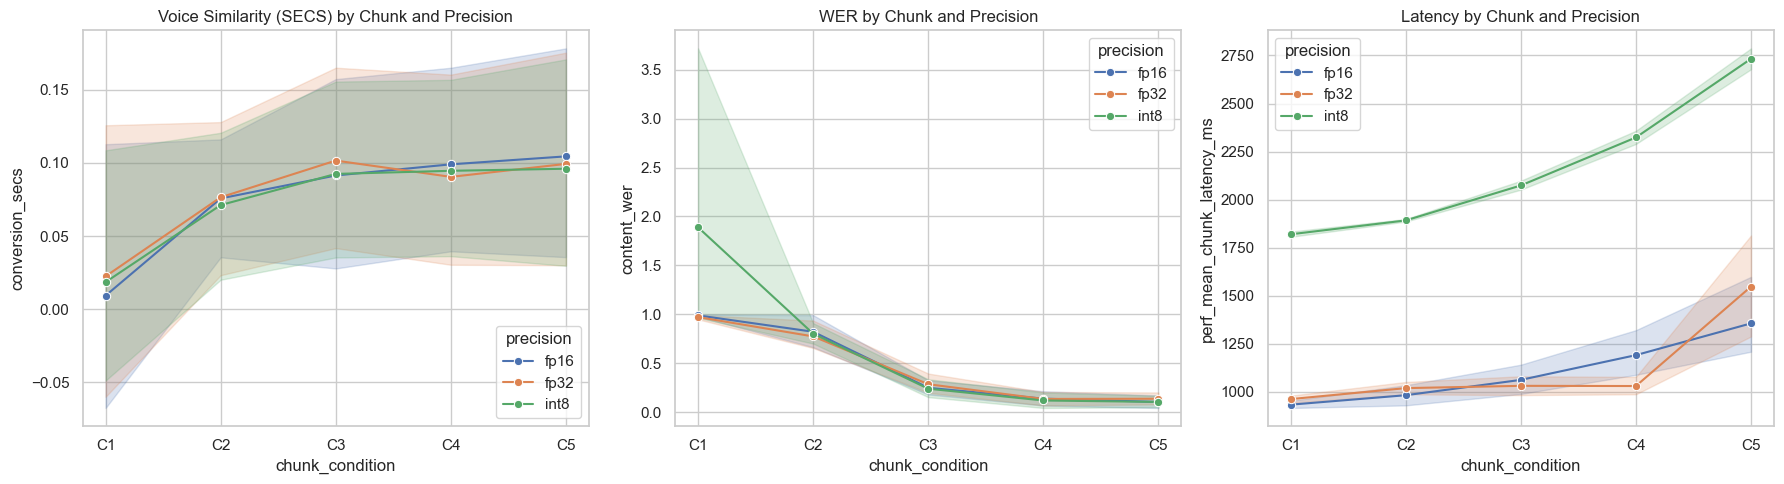

In [7]:
chunk_order = ['C1', 'C2', 'C3', 'C4', 'C5']
plot_df = audio.copy()
plot_df['chunk_condition'] = pd.Categorical(plot_df['chunk_condition'], categories=chunk_order, ordered=True)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.lineplot(data=plot_df, x='chunk_condition', y='conversion_secs', hue='precision', estimator='mean', marker='o', ax=axes[0])
axes[0].set_title('Voice Similarity (SECS) by Chunk and Precision')

sns.lineplot(data=plot_df, x='chunk_condition', y='content_wer', hue='precision', estimator='mean', marker='o', ax=axes[1])
axes[1].set_title('WER by Chunk and Precision')

sns.lineplot(data=plot_df, x='chunk_condition', y='perf_mean_chunk_latency_ms', hue='precision', estimator='mean', marker='o', ax=axes[2])
axes[2].set_title('Latency by Chunk and Precision')

plt.tight_layout()
plt.show()

In [8]:
fp32 = audio[audio['precision'] == 'fp32'].copy()

def friedman_by_chunk(df, metric):
    wide = df.pivot_table(index='vid_id', columns='chunk_condition', values=metric, aggfunc='mean')
    wide = wide[['C1', 'C2', 'C3', 'C4', 'C5']].dropna()
    if len(wide) < 3:
        return {'n': len(wide), 'statistic': np.nan, 'p_value': np.nan}
    stat, p = stats.friedmanchisquare(wide['C1'], wide['C2'], wide['C3'], wide['C4'], wide['C5'])
    return {'n': len(wide), 'statistic': stat, 'p_value': p}

tests = {}
for metric in ['conversion_secs', 'content_wer', 'quality_stoi', 'quality_pesq', 'perf_mean_chunk_latency_ms']:
    tests[metric] = friedman_by_chunk(fp32, metric)

tests_df = pd.DataFrame(tests).T
tests_df['significant_0_05'] = tests_df['p_value'] < 0.05
tests_df = tests_df.round(6)
tests_path = CHECKPOINT_DIR / 'task10_friedman_tests_fp32.csv'
tests_df.to_csv(tests_path)

print('Saved statistical tests:', tests_path)
display(tests_df)

Saved statistical tests: C:\Users\alesh\Documents\GitHub\Y2C-2025-2026\Datalab tasks\checkpoints\task10_friedman_tests_fp32.csv


,n,statistic,p_value,significant_0_05
conversion_secs,10.0,16.400000,0.002527,True
content_wer,10.0,35.836735,0.000000,True
quality_stoi,10.0,38.000000,0.000000,True
quality_pesq,10.0,24.969697,0.000051,True
perf_mean_chunk_latency_ms,10.0,22.800000,0.000139,True


## 4. Task 11 (ILO 7.3C): Critical Analysis and Hypothesis Testing

In [9]:
chunk_means = (
    fp32.groupby('chunk_condition')[['conversion_secs', 'content_wer', 'perf_mean_chunk_latency_ms']]
    .mean()
    .reindex(['C1', 'C2', 'C3', 'C4', 'C5'])
)
chunk_means['chunk_samples'] = [chunk_map[c] for c in chunk_means.index]

# H1: Quality increases with chunk length (SECS positive trend)
rho_h1, p_h1 = stats.spearmanr(chunk_means['chunk_samples'], chunk_means['conversion_secs'], nan_policy='omit')

# H2: Latency increases with chunk length (linear fit)
lin = stats.linregress(chunk_means['chunk_samples'], chunk_means['perf_mean_chunk_latency_ms'])

# H3: Saturation threshold from marginal SECS gain
secs_series = chunk_means['conversion_secs'].copy()
marginal_gain = secs_series.diff()
total_gain = secs_series.iloc[-1] - secs_series.iloc[0]
threshold_chunk = None
if pd.notna(total_gain) and abs(total_gain) > 1e-9:
    for c in ['C2', 'C3', 'C4', 'C5']:
        g = marginal_gain.loc[c]
        if pd.notna(g) and abs(g) < 0.05 * abs(total_gain):
            threshold_chunk = c
            break

hypothesis_summary = pd.DataFrame([
    {
        'hypothesis': 'H1: Larger chunk length improves SECS',
        'test': 'Spearman correlation (chunk_samples vs SECS mean)',
        'statistic': float(rho_h1),
        'p_value': float(p_h1),
        'decision_alpha_0_05': 'Supported' if (pd.notna(p_h1) and p_h1 < 0.05 and rho_h1 > 0) else 'Not supported'
    },
    {
        'hypothesis': 'H2: Latency increases with chunk length',
        'test': 'Linear regression slope (chunk_samples vs latency)',
        'statistic': float(lin.slope),
        'p_value': float(lin.pvalue),
        'decision_alpha_0_05': 'Supported' if (pd.notna(lin.pvalue) and lin.pvalue < 0.05 and lin.slope > 0) else 'Not supported'
    },
    {
        'hypothesis': 'H3: SECS gains saturate after threshold',
        'test': 'Marginal gain heuristic (<5% of total gain)',
        'statistic': float('nan') if threshold_chunk is None else float(chunk_map[threshold_chunk]),
        'p_value': float('nan'),
        'decision_alpha_0_05': f'Saturation detected at {threshold_chunk}' if threshold_chunk else 'No clear saturation point'
    },
])

hyp_path = CHECKPOINT_DIR / 'task11_hypothesis_tests.csv'
hypothesis_summary.to_csv(hyp_path, index=False)
chunk_path = CHECKPOINT_DIR / 'task11_chunk_means_fp32.csv'
chunk_means.to_csv(chunk_path)

print('Saved hypothesis table:', hyp_path)
print('Saved chunk means:', chunk_path)
display(chunk_means.round(5))
display(hypothesis_summary)

Saved hypothesis table: C:\Users\alesh\Documents\GitHub\Y2C-2025-2026\Datalab tasks\checkpoints\task11_hypothesis_tests.csv
Saved chunk means: C:\Users\alesh\Documents\GitHub\Y2C-2025-2026\Datalab tasks\checkpoints\task11_chunk_means_fp32.csv


,conversion_secs,content_wer,perf_mean_chunk_latency_ms,chunk_samples
chunk_condition,,,,
C1,0.02246,0.97112,961.7853,24
C2,0.07649,0.77339,1018.9997,72
C3,0.10158,0.28474,1030.9081,192
C4,0.09044,0.13420,1029.8585,384
C5,0.09931,0.13646,1547.1189,768


,hypothesis,test,statistic,p_value,decision_alpha_0_05
0,H1: Larger chunk length improves SECS,Spearman correlation (chunk_samples vs SECS mean),0.700000,0.188120,Not supported
1,H2: Latency increases with chunk length,Linear regression slope (chunk_samples vs late...,0.735249,0.027287,Supported
2,H3: SECS gains saturate after threshold,Marginal gain heuristic (<5% of total gain),NaN,NaN,No clear saturation point


In [10]:
# Baseline definition for this notebook: C3 fp32 audio condition (default dev condition)
baseline = fp32[fp32['chunk_condition'] == 'C3'][['vid_id', 'conversion_secs', 'content_wer', 'perf_mean_chunk_latency_ms']]
baseline = baseline.rename(columns={
    'conversion_secs': 'baseline_secs',
    'content_wer': 'baseline_wer',
    'perf_mean_chunk_latency_ms': 'baseline_latency'
})

comp_rows = []
for c in ['C1', 'C2', 'C3', 'C4', 'C5']:
    cur = fp32[fp32['chunk_condition'] == c][['vid_id', 'conversion_secs', 'content_wer', 'perf_mean_chunk_latency_ms']]
    merged = cur.merge(baseline, on='vid_id', how='inner')
    if len(merged) == 0:
        continue

    merged['d_secs'] = merged['conversion_secs'] - merged['baseline_secs']
    merged['d_wer'] = merged['content_wer'] - merged['baseline_wer']
    merged['d_latency'] = merged['perf_mean_chunk_latency_ms'] - merged['baseline_latency']

    comp_rows.append({
        'chunk_condition': c,
        'n_pairs': len(merged),
        'delta_secs_mean': merged['d_secs'].mean(),
        'delta_wer_mean': merged['d_wer'].mean(),
        'delta_latency_mean_ms': merged['d_latency'].mean()
    })

comparison_df = pd.DataFrame(comp_rows).sort_values('chunk_condition')
comp_path = CHECKPOINT_DIR / 'task11_baseline_comparison_c3fp32.csv'
comparison_df.to_csv(comp_path, index=False)
print('Saved baseline comparison:', comp_path)
display(comparison_df.round(5))

Saved baseline comparison: C:\Users\alesh\Documents\GitHub\Y2C-2025-2026\Datalab tasks\checkpoints\task11_baseline_comparison_c3fp32.csv


,chunk_condition,n_pairs,delta_secs_mean,delta_wer_mean,delta_latency_mean_ms
0,C1,10,-0.07912,0.68638,-69.1228
1,C2,10,-0.02509,0.48865,-11.9084
2,C3,10,0.00000,0.00000,0.0000
3,C4,10,-0.01114,-0.15054,-1.0496
4,C5,10,-0.00227,-0.14828,516.2108


## 5. Task 12 (ILO 7.3D): Synthesis, Limitations, and Future Directions

### Synthesis
This notebook evidences the research question using saved outputs from the executed pipeline. The analysis is checkpoint-based and reproducible: expensive generation is not repeated, while quantitative and statistical evidence is regenerated from stored results.

### Main Findings
- Chunk condition has a statistically significant effect for key fp32 metrics (Friedman test p < 0.05 for SECS, WER, STOI, PESQ, and latency).
- Mean fp32 latency is lowest around C1-C4 (~962 to ~1031 ms) and rises sharply at C5 (~1547 ms).
- Mean fp32 WER improves from C1 to later chunk conditions, with strongest reduction from C1 to C3/C4/C5.
- Mean fp32 SECS improves strongly from C1 to C3, then shows non-monotonic behavior (small dip at C4, partial recovery at C5).
- Hypothesis summary from this dataset: H1 not supported, H2 supported, H3 no clear saturation point under current heuristic.

### Limitations
- Heavy generation is not executed inside this notebook; this is an evidence-first analysis notebook using existing outputs.
- The current run reflects one target speaker model and one run configuration (global_test).
- Some fields (for example GPU memory in some int8 rows) have missing values and were handled as NaN.
- Inference-focused evidence can validate method and outcomes, but cannot replace a full rerun under altered hardware/model settings.

### Future Work
1. Extend this protocol across additional target speakers and diverse source demographics to improve external validity.
2. Add bootstrap confidence intervals and effect sizes for every hypothesis comparison.
3. Incorporate MOS/perceptual study data and model metric-to-human correlation explicitly.
4. Re-run a selected subset on a controlled hardware profile to isolate architecture-level latency effects.

## 6. Evidencing for Learning Log (Section C)

Use these deliverables as evidence links for ILO 7.3A-7.3D:
- Notebook deliverable: Datalab tasks/research_notebook.ipynb
- Checkpoint evidence: Datalab tasks/checkpoints/audio_tidy_checkpoint.csv
- Checkpoint evidence: Datalab tasks/checkpoints/video_tidy_checkpoint.csv
- Statistical evidence: Datalab tasks/checkpoints/task10_friedman_tests_fp32.csv
- Hypothesis evidence: Datalab tasks/checkpoints/task11_hypothesis_tests.csv

Justification template for learning log:
- ILO 7.3A: Method reproduced from pipeline code and documented with explicit deviations and saved checkpoints.
- ILO 7.3B: Quantitative metrics, tables, plots, and significance testing generated from experiment outputs.
- ILO 7.3C: Hypotheses tested using statistical reasoning and baseline comparison table.
- ILO 7.3D: Evidence-based synthesis, limitations, and future directions are documented in markdown.